In [1]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
import pandas as pd
from matplotlib.ticker import ScalarFormatter
from utils import load_and_split, get_teacher_embeddings, make_activation_figs, make_depth_figs, prep, flatten_cols
import dataframe_image as dfi
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-30 11:58:31.324372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759247911.339762   88196 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759247911.344442   88196 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759247911.358599   88196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [22]:
pd.read_csv('/user/bnc2119/drd/GBM_HVG500_with_metadata.csv', index_col=0).iloc[:, 29:].min().min()

np.float64(0.0)

In [14]:
# build the styled table
styles = [
    # collapse borders so they’re shared
    {"selector": "table", "props": [("border-collapse", "collapse")]},

    # default 1px light‐gray grid
    {"selector": "th, td", 
     "props": [("border", "1px solid #ccc"), ("padding", "5px")]},

    # thick line below each teacher group
    {"selector": "tbody th.row_heading.level0",
     "props": [("border-bottom", "3px solid #444")]}
]

def get_cols(agg):
    distill_cols = agg.columns[(agg.columns.get_level_values(0) == "distill_loss") &
        (agg.columns.get_level_values(1) == "mean")]
    recon_cols   = agg.columns[(agg.columns.get_level_values(0) == "recon_loss") &
        (agg.columns.get_level_values(1) == "mean")]
    time_cols    = agg.columns[(agg.columns.get_level_values(0) == "time_total_s") &
        (agg.columns.get_level_values(1) == "mean")]
    return distill_cols, recon_cols, time_cols

In [4]:
dataset, nb = "single_cell", 10
analysis_umap = pd.read_csv(f'/shared/share_mala/irchang/drd/tune_results/{dataset}_umap_neigh{nb}.csv')
analysis_umap['teacher'] = f"umap_neigh{nb}"
analysis_pca = pd.read_csv(f'/shared/share_mala/irchang/drd/tune_results/{dataset}_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_isomap = pd.read_csv(f'/shared/share_mala/irchang/drd/tune_results/{dataset}_isomap_neigh{nb}.csv')
analysis_isomap['teacher'] = f"isomap_neigh{nb}"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_isomap], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  
agg = prep(agg)

import ast
def parse_list(x):
    if isinstance(x, str):
        return list(ast.literal_eval(x))
    return list(x)

agg['hidden_list'] = agg['hidden_dims'].apply(parse_list)
agg['n_layers']    = agg['hidden_list'].apply(len)
agg['widest_pos']  = agg['hidden_list'].apply(lambda w: int(np.argmax(w)))  # 0=closest to input
agg['widest_tag']  = agg['widest_pos'].map(lambda i: {0:'early', 1:'early-mid', 2:'mid', 3:'late-mid', 4:'late'}.get(i, f'L{i}'))


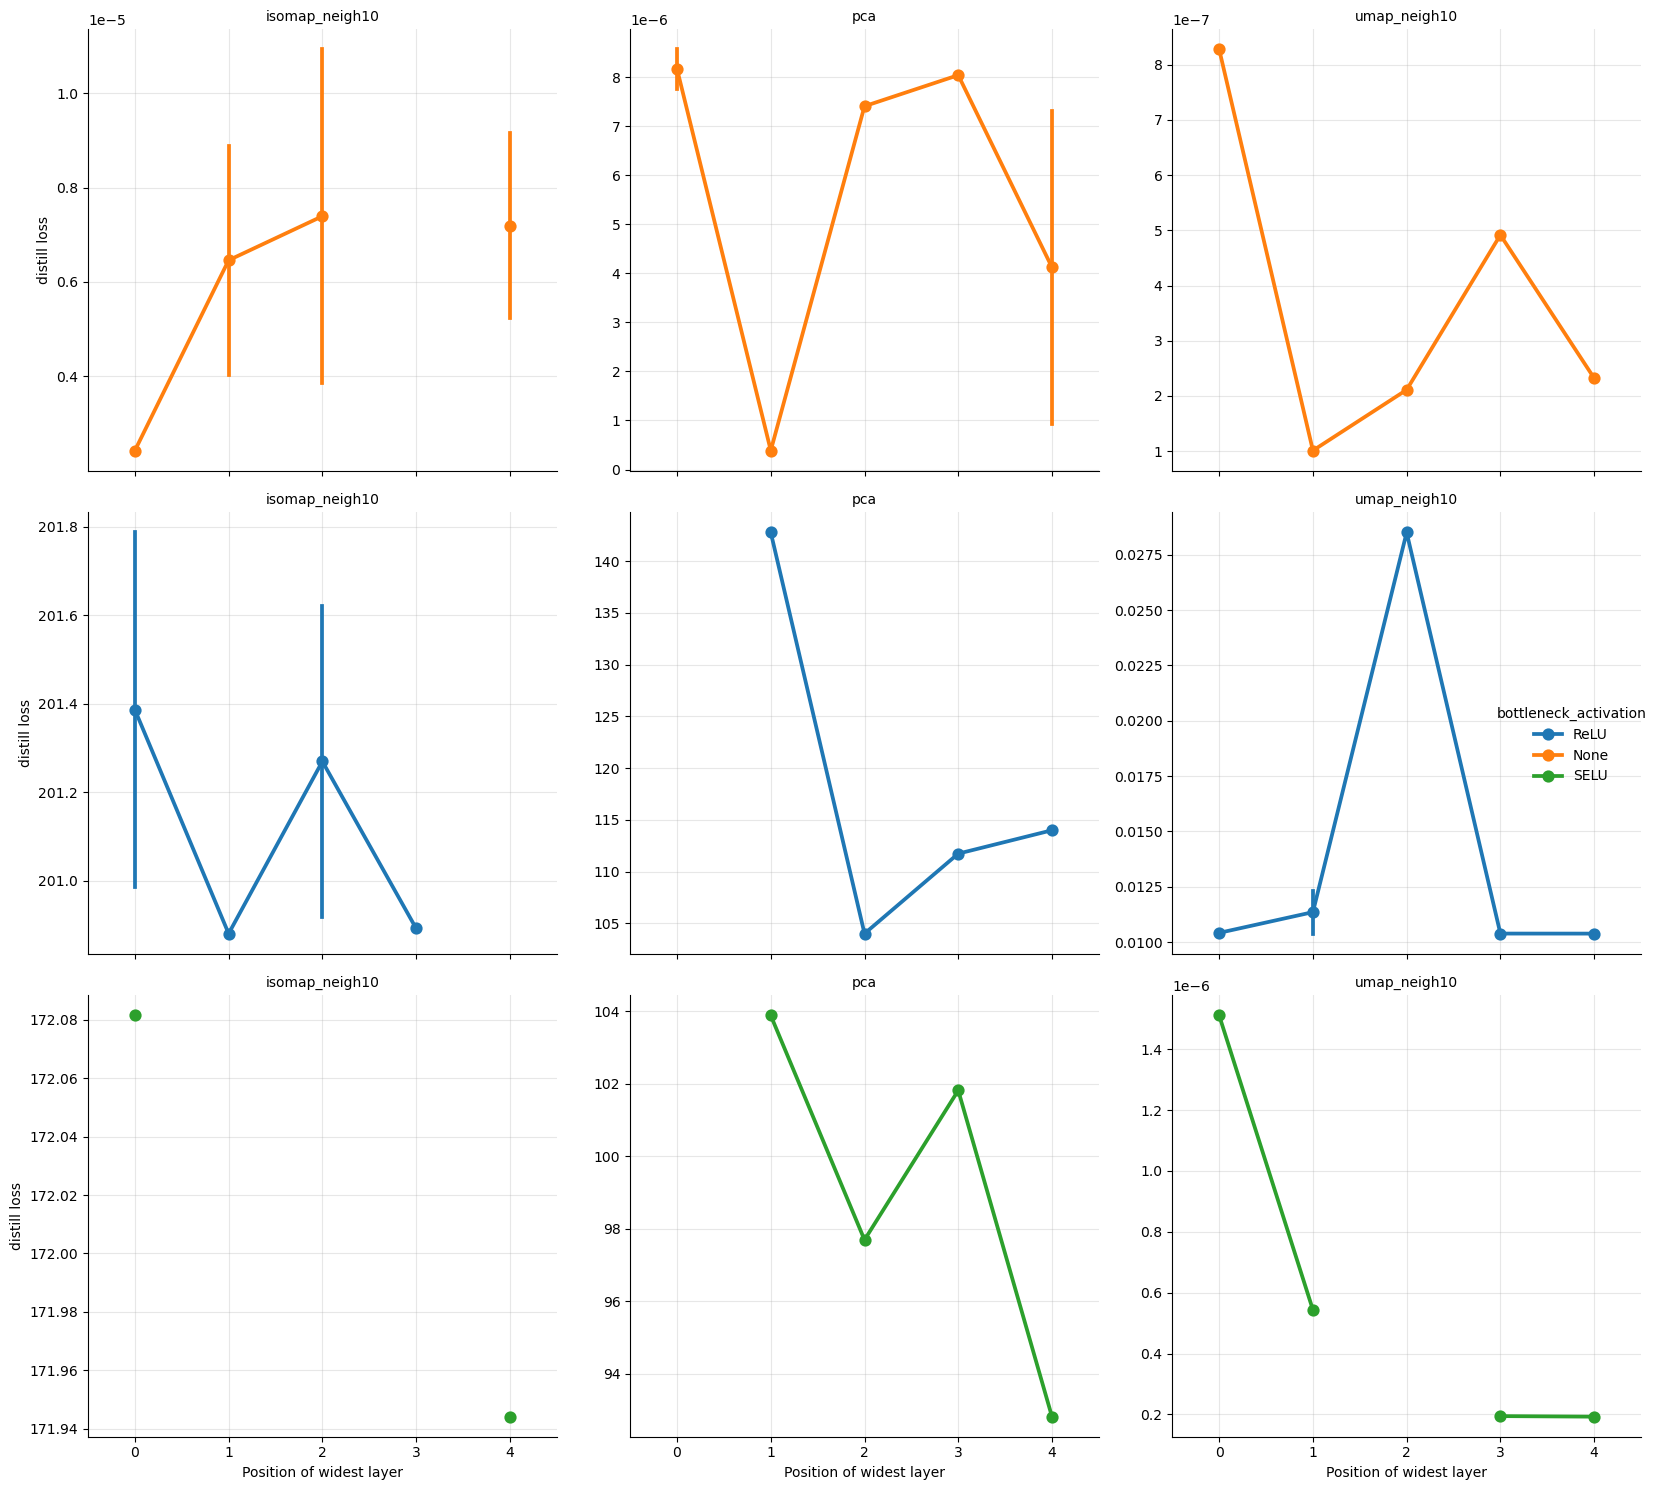

In [80]:
for metric in ["distill_loss"]:
    g = sns.catplot(
        data=agg, x='widest_pos', y=metric,
        col='teacher', row='bottleneck_activation', kind='point', sharey=False, hue='bottleneck_activation',
        errorbar=('ci',95)
    )
    g.set_axis_labels("Position of widest layer", metric.replace('_',' '))
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.grid(True, alpha=.3)
    plt.tight_layout()

In [18]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_wine_umap.csv')
analysis_umap['teacher'] = "umap_neigh15"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_wine_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_isomap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_wine_isomap.csv')
analysis_isomap['teacher'] = "isomap_neigh15"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_wine_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_isomap, analysis_tsne], ignore_index=True)
# analysis = pd.concat([analysis_pca_depth, analysis_umap_depth, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  

# distill_cols, recon_cols, time_cols = get_cols(agg)
# (
#     agg.style
#       .background_gradient(
#           subset=distill_cols,
#           cmap="Blues",
#           vmin=agg[distill_cols].min().min(),
#           vmax=agg[distill_cols].max().max()
#        )
#       .background_gradient(
#           subset=recon_cols,
#           cmap="Oranges",
#           vmin=agg[recon_cols].min().min(),
#           vmax=agg[recon_cols].max().max()
#        )
#        .background_gradient(
#           subset=time_cols,
#           cmap="Greens",
#           vmin=agg[time_cols].min().min(),
#           vmax=agg[time_cols].max().max()
#        )
#       .format({
#           **{col: "{:.4e}"  for col in distill_cols},    
#           **{col: "{:.6f}" for col in recon_cols}        
#        })
#       .set_caption("Distill & Recon Loss (mean/std/count)")
#       .set_table_styles(styles)
# )

/tmp/ipykernel_41926/3007659458.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


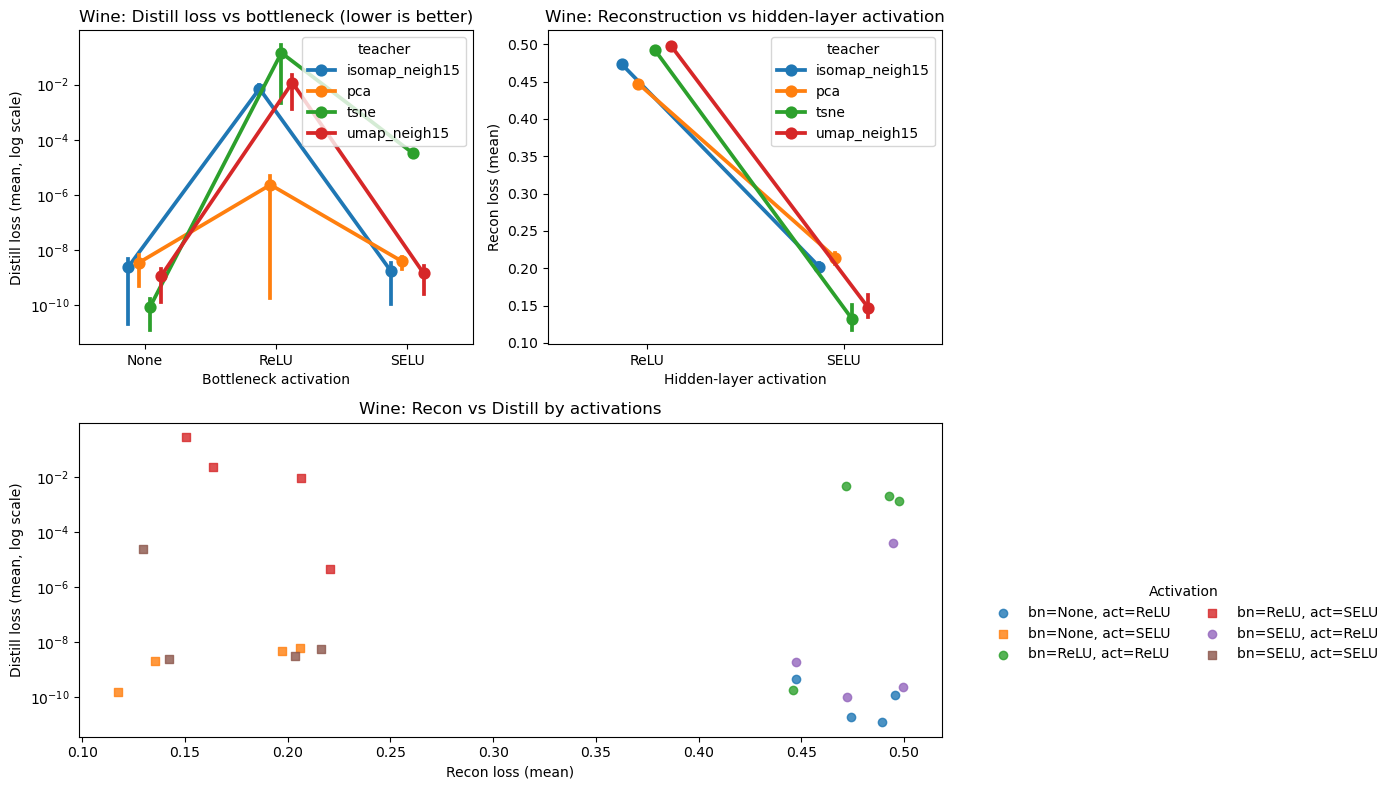

In [6]:
make_activation_figs(agg, task_name="Wine")

In [12]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_gene_cancer_umap.csv')
analysis_umap['teacher'] = "umap_neigh10"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_gene_cancer_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_isomap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_gene_cancer_isomap.csv')
analysis_isomap['teacher'] = "isomap_neigh10"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_gene_cancer_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_isomap, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  

/tmp/ipykernel_113399/2927737642.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


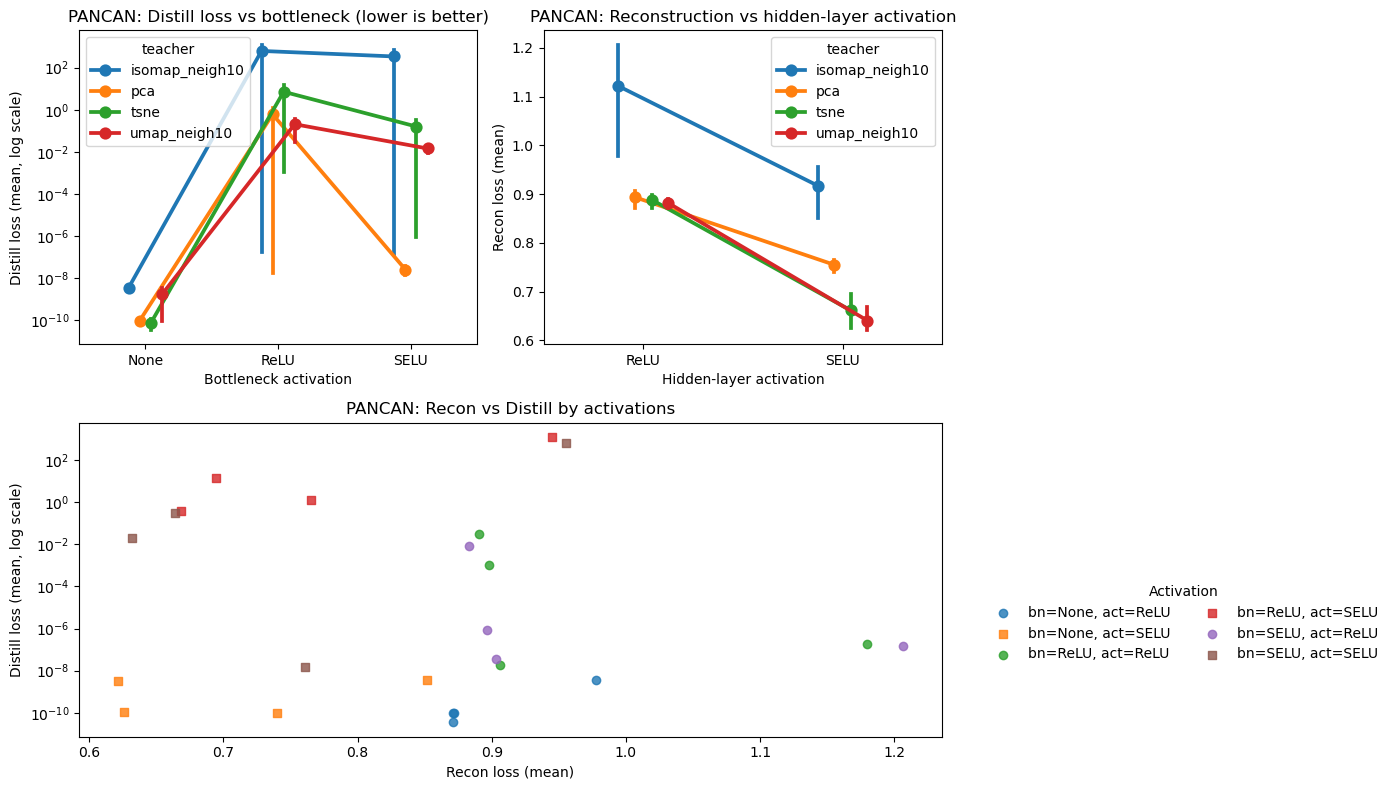

In [8]:
make_activation_figs(agg, task_name="PANCAN")

In [15]:
# this experiment marginalizes over all other tuning hyperparameters (lr, eta_min, etc)
# mnist data, pca teacher
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_mnist_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_mnist_umap.csv')
analysis_umap['teacher'] = "umap_neigh15"
analysis_isomap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_mnist_isomap.csv')
analysis_isomap['teacher'] = "isomap_neigh15"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_mnist_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_pca, analysis_umap, analysis_isomap, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  


/tmp/ipykernel_113399/929081364.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


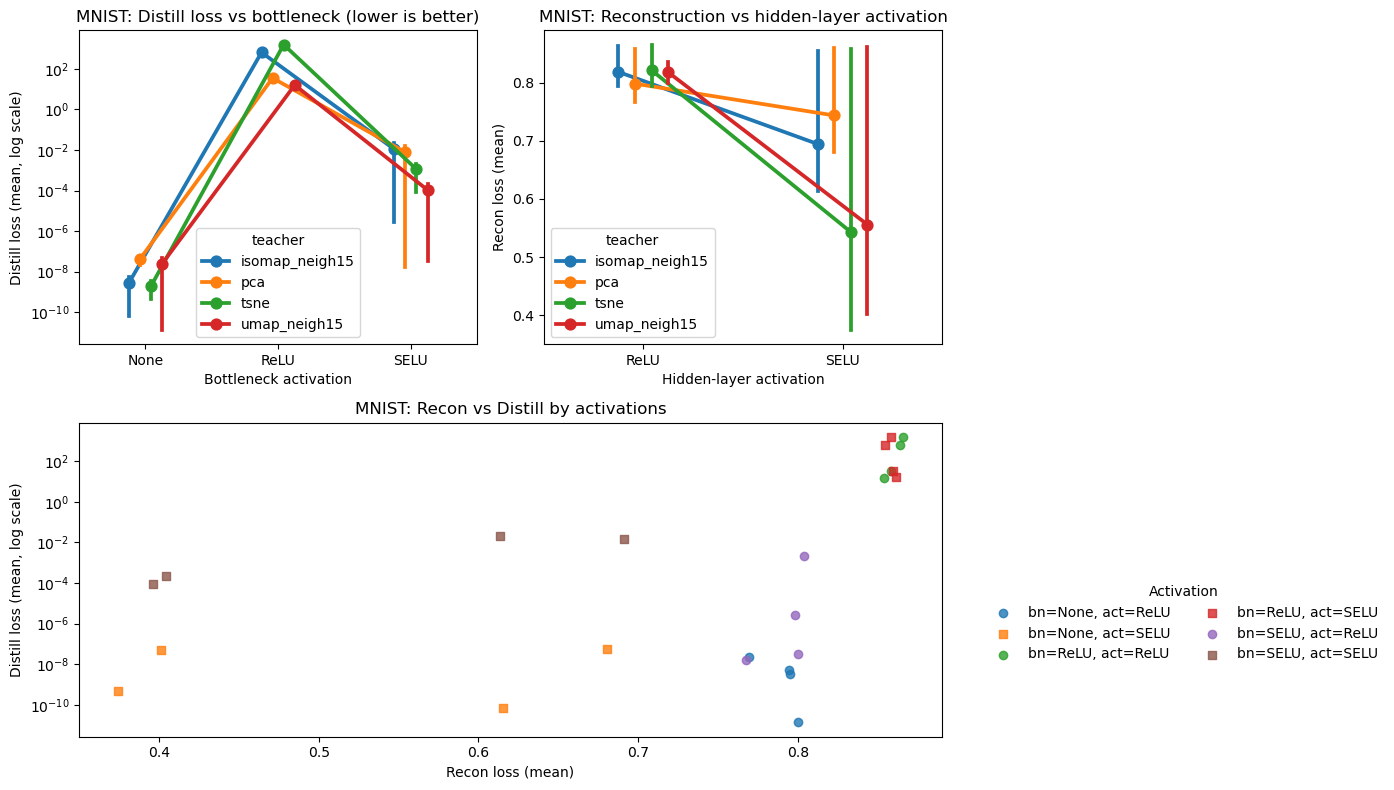

In [10]:
make_activation_figs(agg, task_name="MNIST")

In [14]:
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/diabetes_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/diabetes_umap_neigh10.csv')
analysis_umap['teacher'] = "umap_neigh10"
analysis_isomap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/diabetes_isomap_neigh10.csv')
analysis_isomap['teacher'] = "isomap_neigh10"
analysis = pd.concat([analysis_pca, analysis_umap, analysis_isomap], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  


In [13]:
pd.set_option('display.float_format', '{:.6e}'.format)
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_single_cell_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_single_cell_umap_10.csv')
analysis_umap['teacher'] = "umap_neigh10"
analysis_isomap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_single_cell_isomap_neigh10.csv')
analysis_isomap['teacher'] = "isomap_neigh10"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/activation_single_cell_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_pca, analysis_umap, analysis_isomap, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  


/tmp/ipykernel_113399/3250060224.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


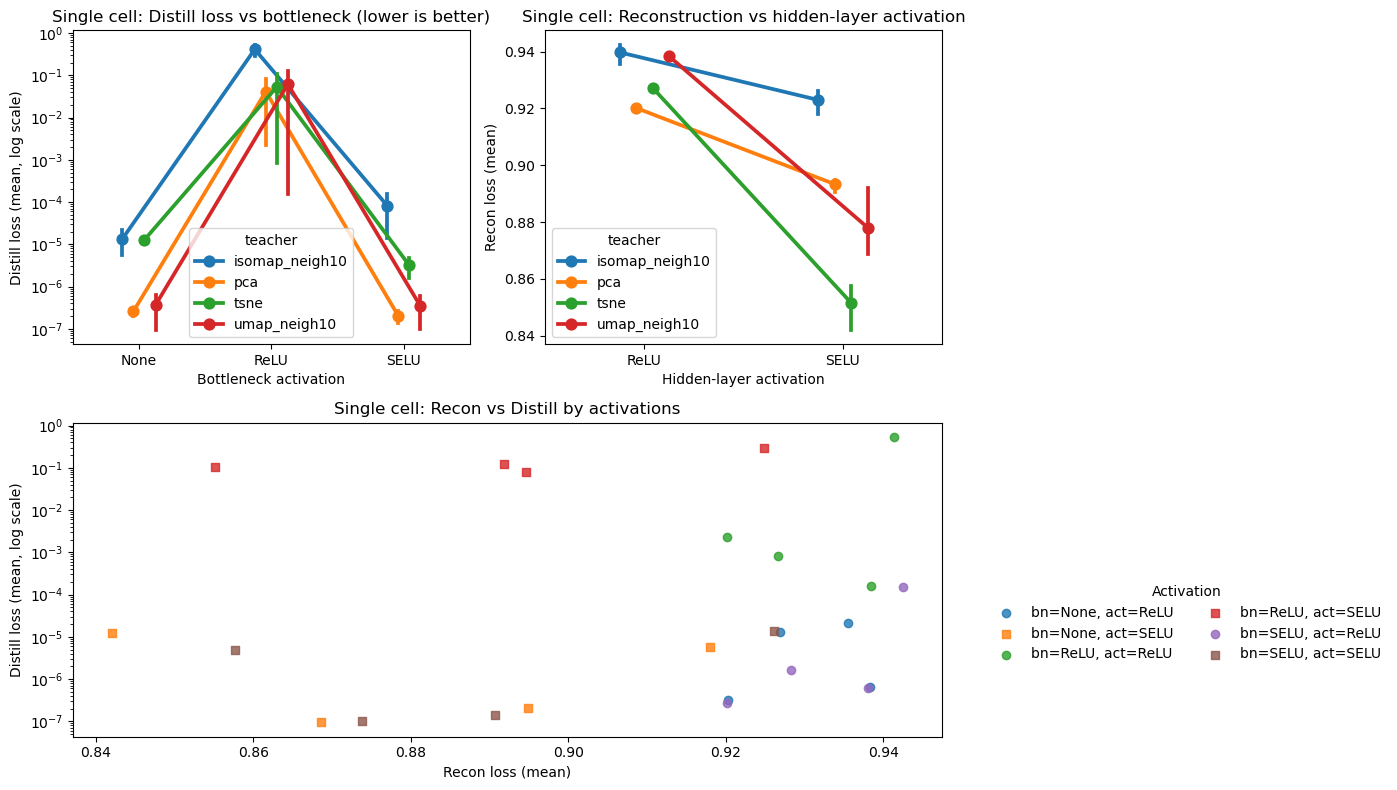

In [17]:
make_activation_figs(agg, task_name="Single cell")

In [7]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/hydra_umap.csv')
# analysis.fillna('None', inplace=True) 
# analysis['teacher'] = "tsne"
# make_depth_figs(analysis, task_name="Hydra")
analysis[['config/hidden_dims', 'distill_loss']].sort_values('distill_loss').head(10)

,config/hidden_dims,distill_loss
18,"[2000, 2000, 2000, 2000, 2000, 2000]",1.083846e-07
5,"[2000, 2000, 2000, 2000]",8.573364e-07
15,"[2000, 2000, 2000, 2000]",8.885389e-07
8,"[2000, 2000, 2000, 2000, 2000, 2000]",9.018223e-07
10,"[2000, 2000, 2000, 2000, 2000]",1.192186e-06
3,"[2000, 2000, 2000, 2000, 2000, 2000]",1.322253e-05
12,"[2000, 2000, 2000, 2000, 2000, 2000]",1.631704e-05
17,"[2000, 2000, 2000, 2000, 2000]",2.318839e-05
19,"[2000, 2000, 2000, 2000, 2000, 2000]",4.172435e-05
16,"[2000, 2000, 2000, 2000, 2000, 2000]",5.223065e-05


/tmp/ipykernel_122293/3814402492.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


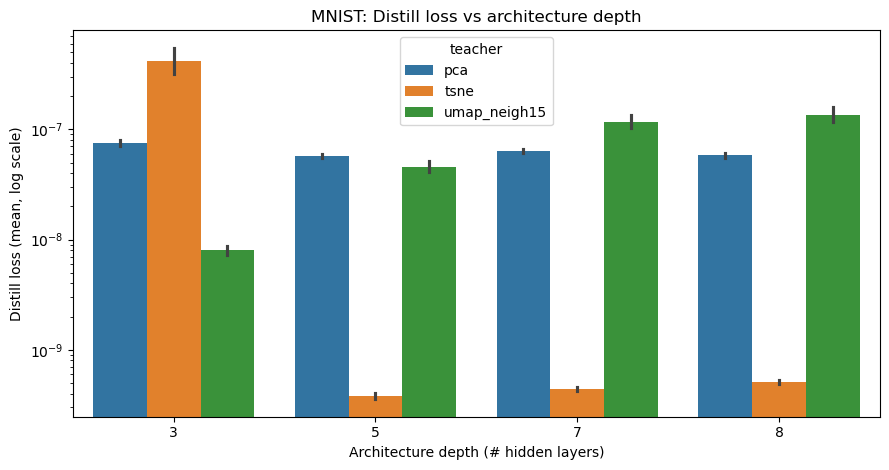

In [ ]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_mnist_umap.csv')
analysis_umap['teacher'] = "umap_neigh15"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_mnist_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_mnist_pca.csv')
analysis_pca['teacher'] = "pca"
analysis = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)
analysis.fillna('None', inplace=True) 

make_depth_figs(analysis, task_name="MNIST")

/tmp/ipykernel_122293/1634066814.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


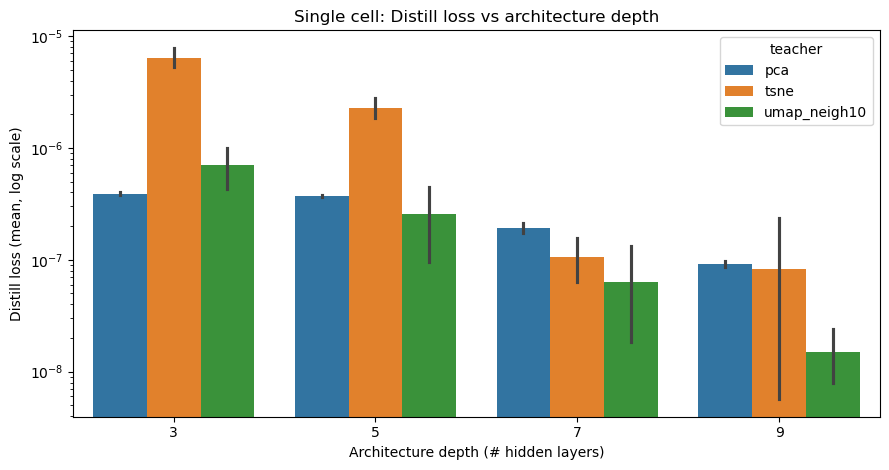

In [11]:
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_single_cell_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_single_cell_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_single_cell_umap.csv')
analysis_umap['teacher'] = "umap_neigh10"
analysis = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)
analysis.fillna('None', inplace=True)

make_depth_figs(analysis, task_name="Single cell")

/tmp/ipykernel_122293/955616788.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


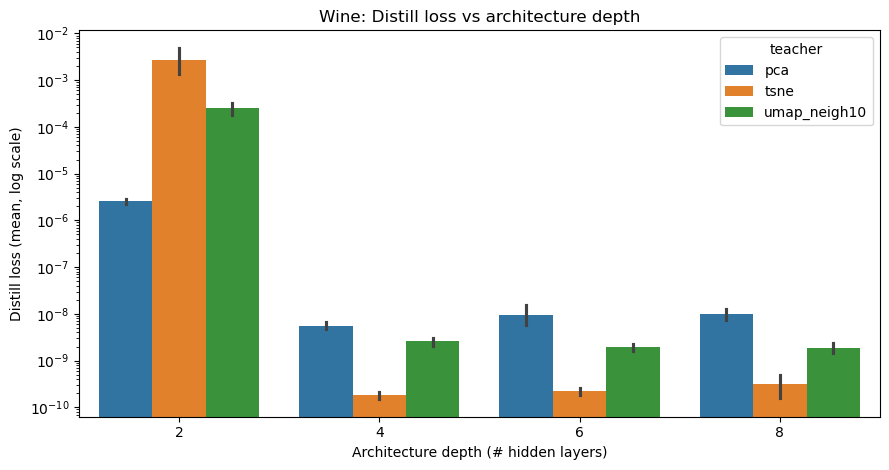

In [12]:
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_wine_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_wine_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_wine_umap.csv')
analysis_umap['teacher'] = "umap_neigh10"
analysis = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)
analysis.fillna('None', inplace=True)

make_depth_figs(analysis, task_name="Wine")

/tmp/ipykernel_122293/2607260039.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


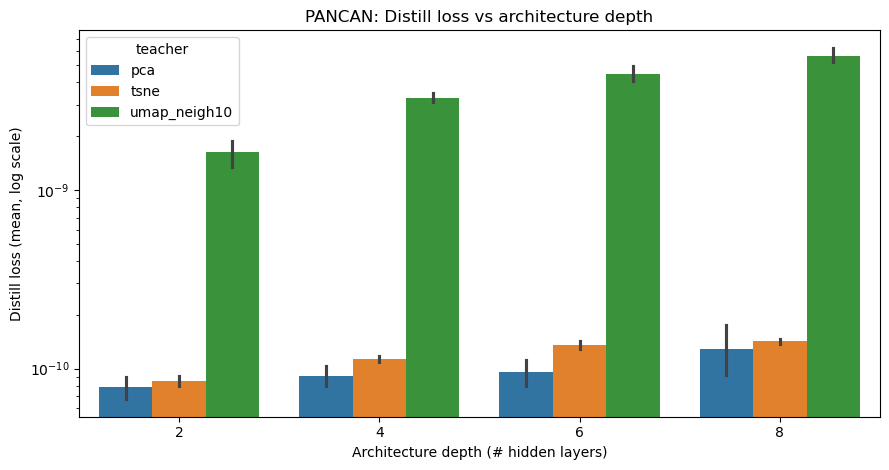

In [13]:
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_gene_cancer_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_gene_cancer_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/depth_gene_cancer_umap.csv')
analysis_umap['teacher'] = "umap_neigh10"
analysis = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)
analysis.fillna('None', inplace=True)  
make_depth_figs(analysis, task_name="PANCAN")

In [15]:
def plot_width(agg, dataset_name, order, tilt=False):
    df = flatten_cols(agg)
    df['bottleneck_activation'] = df['bottleneck_activation'].fillna('None').replace({'nan':'None'})
    df['activation'] = df['activation'].replace({'ReLU':'ReLU', 'SELU':'SELU'})
    plt.figure(figsize=(9,4.8))
    sns.barplot(
        data=df,
        x='hidden_dims', y='distill_loss', hue='teacher',
        estimator='mean', errorbar=('ci', 95),
        order=order
    )
    plt.yscale('log')
    plt.xlabel('Architecture size (hidden layer widths)')
    plt.ylabel('Distill loss (mean, log scale)')
    plt.title(f'{dataset_name}: Distill loss vs Network Size')
    if tilt: plt.xticks(fontsize=6)
    plt.tight_layout()
    plt.show()

def plot_time(agg, dataset_name, order, tilt=False):
    df = flatten_cols(agg)
    plt.figure(figsize=(9,4.8))
    sns.barplot(
        data=df,
        x='hidden_dims', y='time_total_s', hue='teacher',
        estimator='mean', errorbar=('ci', 95),
        order=order
    )
    plt.yscale('log')
    plt.xlabel('Architecture size (hidden layer widths)')
    plt.ylabel('Training time (mean, log scale)')
    plt.title(f'{dataset_name}: Training time vs architecture')
    if tilt: plt.xticks(fontsize=6)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_125815/4246781825.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


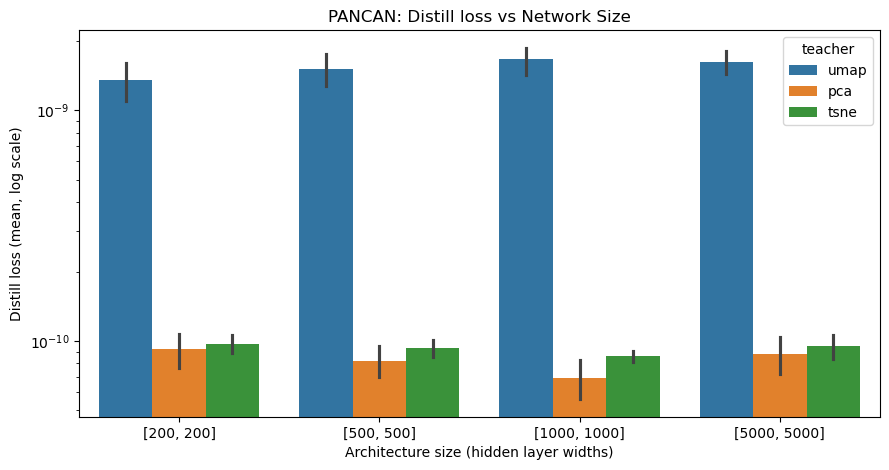

In [16]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_gene_cancer_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_gene_cancer_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_gene_cancer_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)

plot_width(analysis, "PANCAN", ['[200, 200]', '[500, 500]', '[1000, 1000]', '[5000, 5000]'])


/tmp/ipykernel_125815/553557822.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


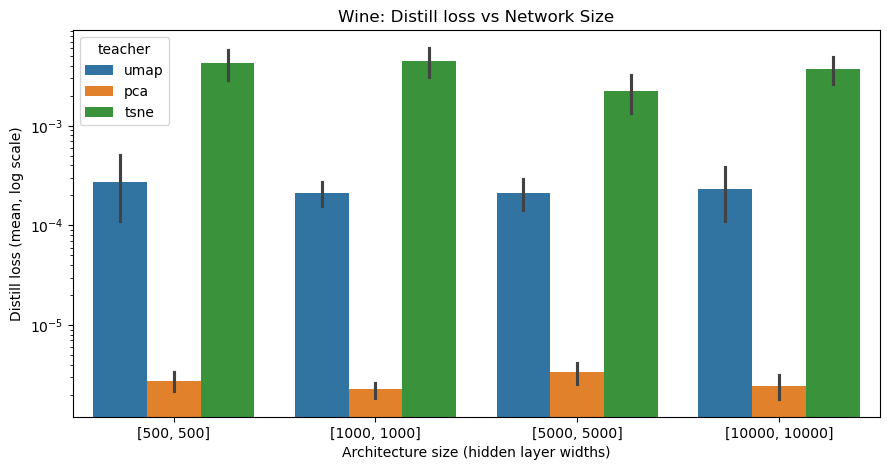

In [17]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_wine_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_wine_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_wine_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True) 

plot_width(analysis, "Wine", ['[500, 500]', '[1000, 1000]', '[5000, 5000]', '[10000, 10000]'])

/tmp/ipykernel_125815/899277554.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


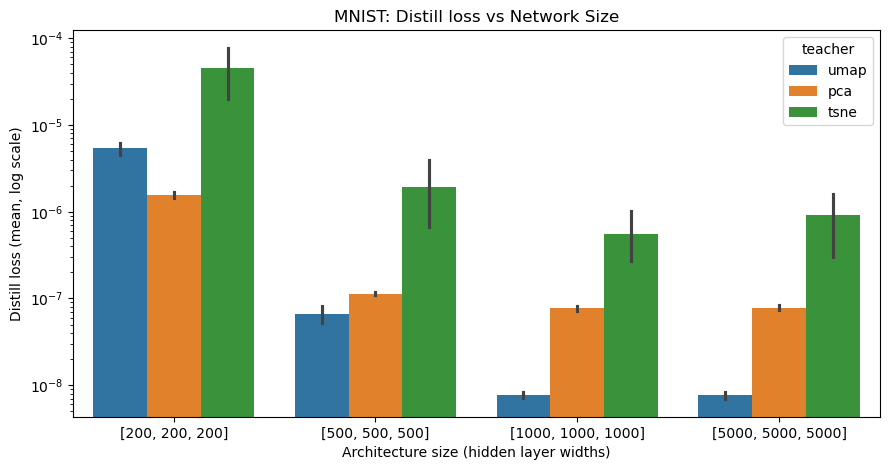

In [18]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_mnist_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_mnist_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_mnist_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  
plot_width(analysis, "MNIST", ['[200, 200, 200]', '[500, 500, 500]', '[1000, 1000, 1000]', '[5000, 5000, 5000]'])

/tmp/ipykernel_122293/4219206183.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


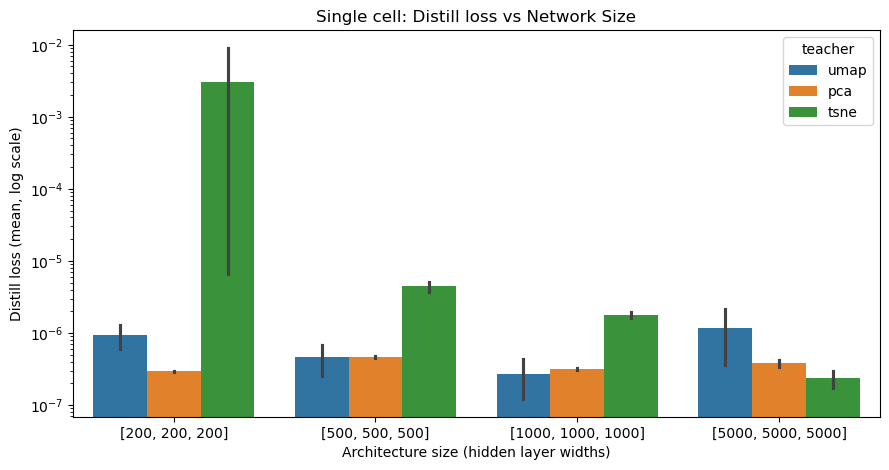

In [28]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_single_cell_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_single_cell_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/size_single_cell_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  
plot_width(analysis, "Single cell", ['[200, 200, 200]', '[500, 500, 500]', '[1000, 1000, 1000]', '[5000, 5000, 5000]'])

/tmp/ipykernel_125815/246294200.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


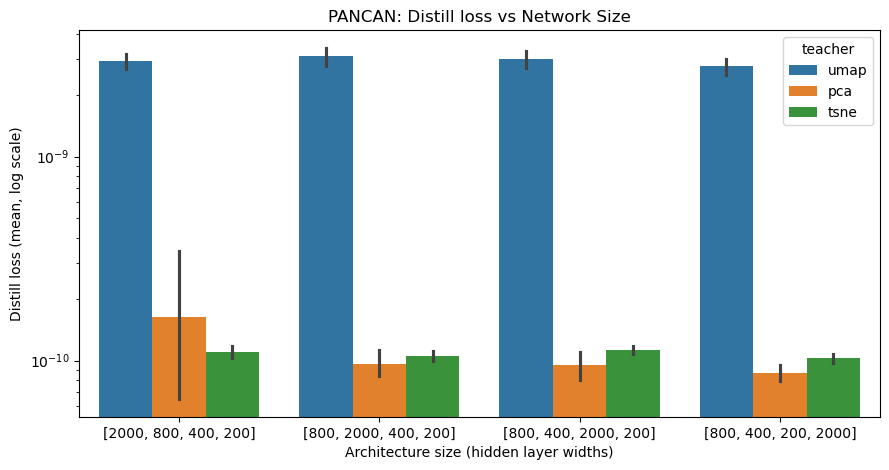

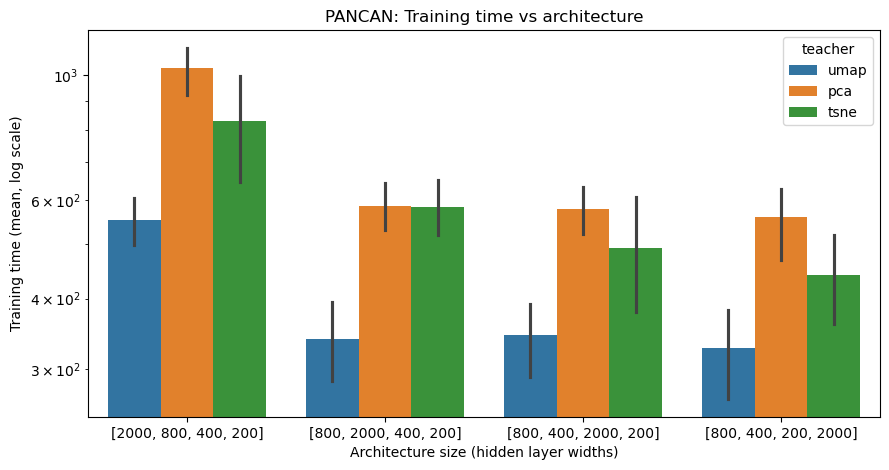

In [10]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_gene_cancer_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_gene_cancer_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_gene_cancer_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  

plot_width(analysis, "PANCAN", ['[2000, 800, 400, 200]', '[800, 2000, 400, 200]', '[800, 400, 2000, 200]', '[800, 400, 200, 2000]'])
plot_time(analysis, "PANCAN", ['[2000, 800, 400, 200]', '[800, 2000, 400, 200]', '[800, 400, 2000, 200]', '[800, 400, 200, 2000]'])

/tmp/ipykernel_125815/873124316.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


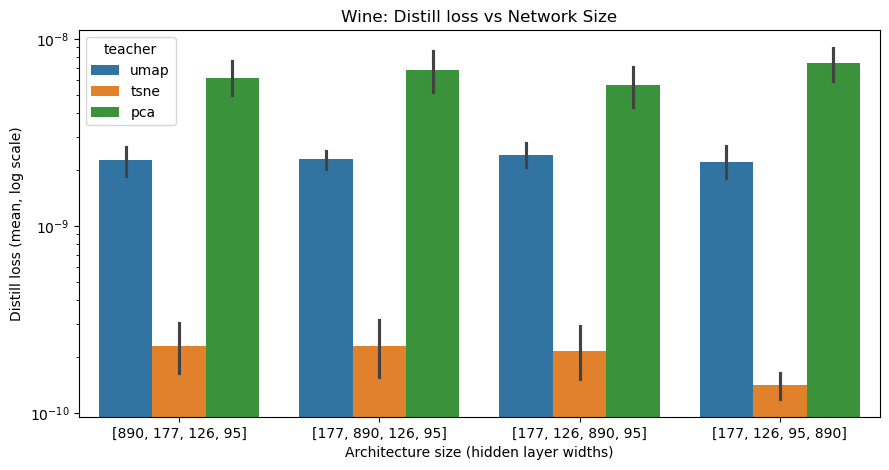

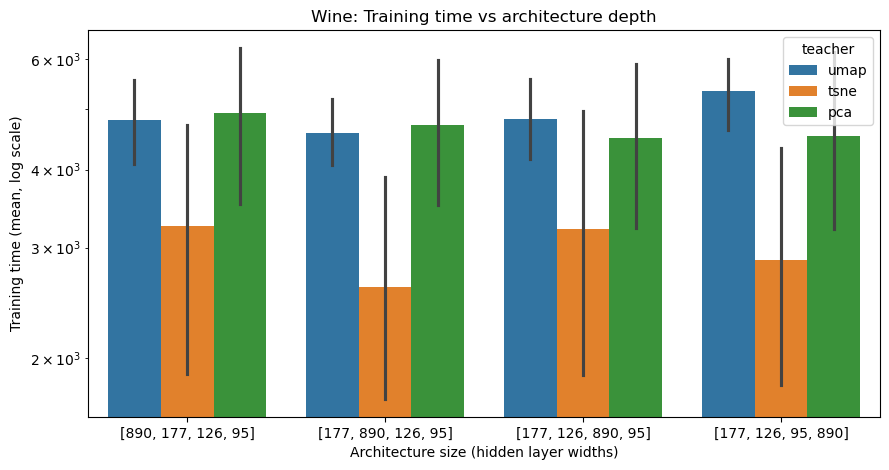

In [6]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_wine_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_wine_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_wine_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_tsne, analysis_pca], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  

plot_width(analysis, "Wine", ['[890, 177, 126, 95]', '[177, 890, 126, 95]', '[177, 126, 890, 95]', '[177, 126, 95, 890]'])
plot_time(analysis, "Wine", ['[890, 177, 126, 95]', '[177, 890, 126, 95]', '[177, 126, 890, 95]', '[177, 126, 95, 890]'])

/tmp/ipykernel_125815/1450584455.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


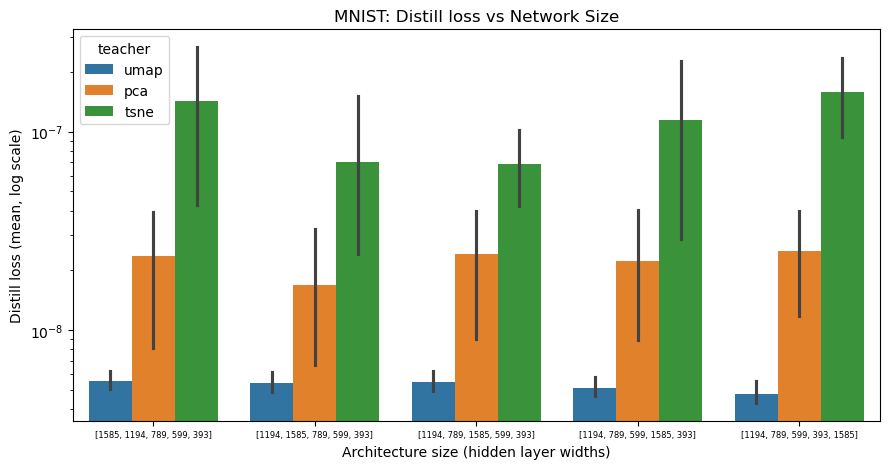

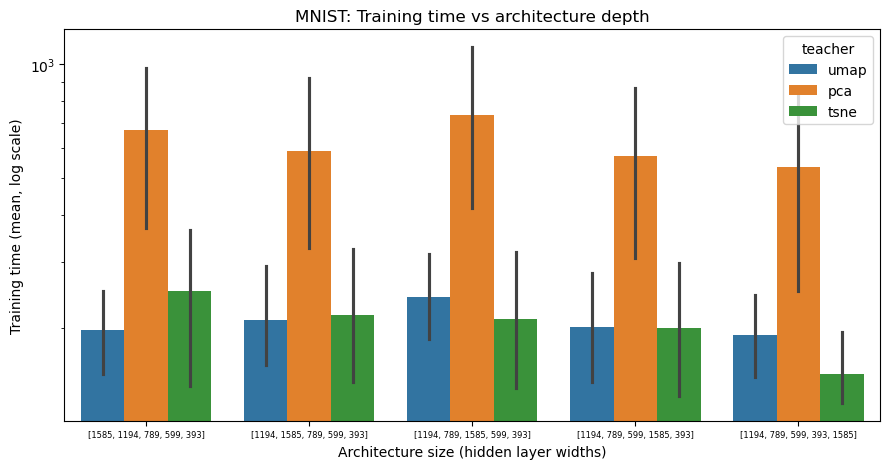

In [7]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_mnist_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_mnist_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_mnist_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)
agg = analysis.groupby(['teacher', 'config/activation', 'config/bottleneck_activation', 'config/hidden_dims']).agg({"distill_loss": ['mean', 'std', 'count'], "recon_loss": ['mean', 'std'], "time_total_s": ['mean']})  

plot_width(analysis, "MNIST", ['[1585, 1194, 789, 599, 393]', '[1194, 1585, 789, 599, 393]', '[1194, 789, 1585, 599, 393]', '[1194, 789, 599, 1585, 393]', '[1194, 789, 599, 393, 1585]'], tilt=True)
plot_time(analysis, "MNIST", ['[1585, 1194, 789, 599, 393]', '[1194, 1585, 789, 599, 393]', '[1194, 789, 1585, 599, 393]', '[1194, 789, 599, 1585, 393]', '[1194, 789, 599, 393, 1585]'], tilt=True)

/tmp/ipykernel_125815/3466975323.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis.fillna('None', inplace=True)


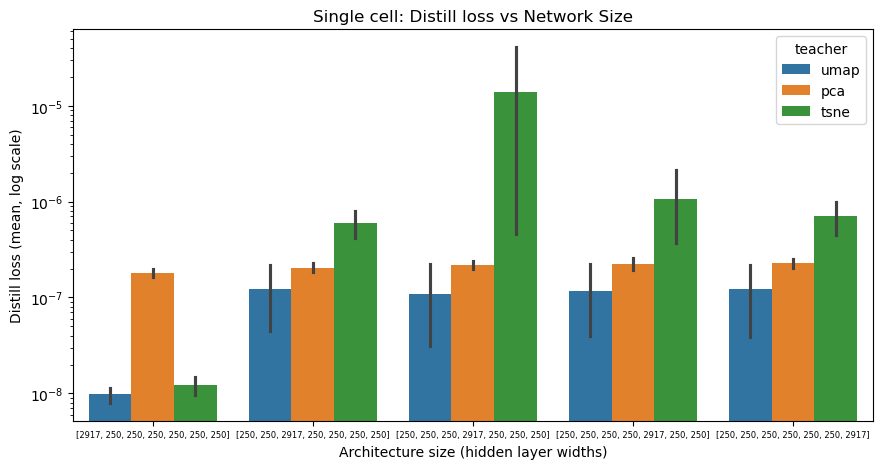

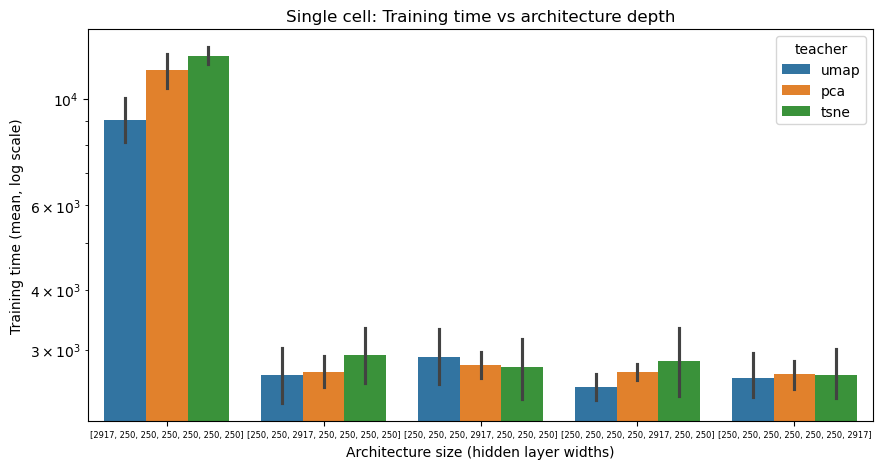

In [ ]:
analysis_umap = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_single_cell_umap.csv')
analysis_umap['teacher'] = "umap"
analysis_pca = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_single_cell_pca.csv')
analysis_pca['teacher'] = "pca"
analysis_tsne = pd.read_csv('/shared/share_mala/irchang/drd/tune_results/pos_single_cell_tsne.csv')
analysis_tsne['teacher'] = "tsne"
analysis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis.fillna('None', inplace=True)

plot_width(analysis, "Single cell", ['[2917, 250, 250, 250, 250, 250, 250]',
                         '[250, 250, 2917, 250, 250, 250, 250]',
                         '[250, 250, 250, 2917, 250, 250, 250]', 
                         '[250, 250, 250, 250, 2917, 250, 250]',
                         '[250, 250, 250, 250, 250, 250, 2917]',], tilt=True)
plot_time(analysis, "Single cell", ['[2917, 250, 250, 250, 250, 250, 250]',
                         '[250, 250, 2917, 250, 250, 250, 250]',
                         '[250, 250, 250, 2917, 250, 250, 250]', 
                         '[250, 250, 250, 250, 2917, 250, 250]',
                         '[250, 250, 250, 250, 250, 250, 2917]',], tilt=True)